In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


In [3]:
df=pd.read_csv(r"C:\Users\seven\Downloads\Salary Data.csv")

In [4]:
df.head()

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0
1,28.0,Female,Master's,Data Analyst,3.0,65000.0
2,45.0,Male,PhD,Senior Manager,15.0,150000.0
3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0
4,52.0,Male,Master's,Director,20.0,200000.0


In [6]:
df.isnull().sum()

Age                    2
Gender                 2
Education Level        2
Job Title              2
Years of Experience    2
Salary                 2
dtype: int64

In [7]:
df = df.dropna(how='all')

In [8]:
# Convert Salary to numeric, coercing errors to NaN
df['Salary'] = pd.to_numeric(df['Salary'], errors='coerce')

In [11]:
# Drop rows with NaN Salary 
df = df.dropna(subset=['Salary'])

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 373 entries, 0 to 374
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  373 non-null    float64
 1   Gender               373 non-null    object 
 2   Education Level      373 non-null    object 
 3   Job Title            373 non-null    object 
 4   Years of Experience  373 non-null    float64
 5   Salary               373 non-null    float64
dtypes: float64(3), object(3)
memory usage: 20.4+ KB


### Exploratory Data Analysis (EDA)


In [13]:
df.describe()

,Age,Years of Experience,Salary
count,373.000000,373.000000,373.000000
mean,37.431635,10.030831,100577.345845
std,7.069073,6.557007,48240.013482
min,23.000000,0.000000,350.000000
25%,31.000000,4.000000,55000.000000
50%,36.000000,9.000000,95000.000000
75%,44.000000,15.000000,140000.000000
max,53.000000,25.000000,250000.000000


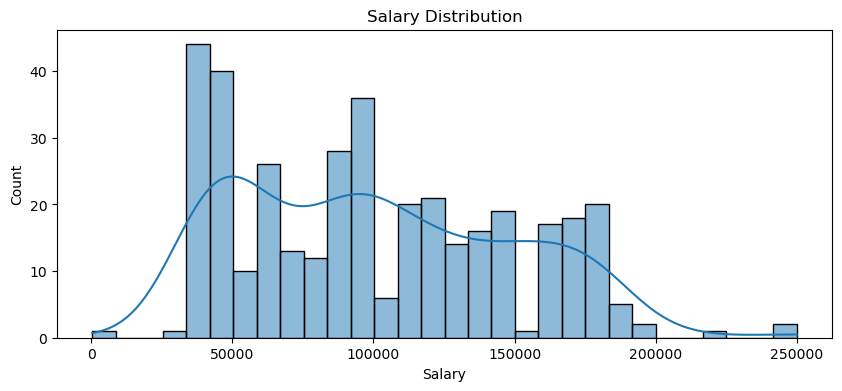

In [14]:

# Distribution of Salary
plt.figure(figsize=(10,4))
sns.histplot(df['Salary'], bins=30, kde=True)
plt.title('Salary Distribution')
plt.show()


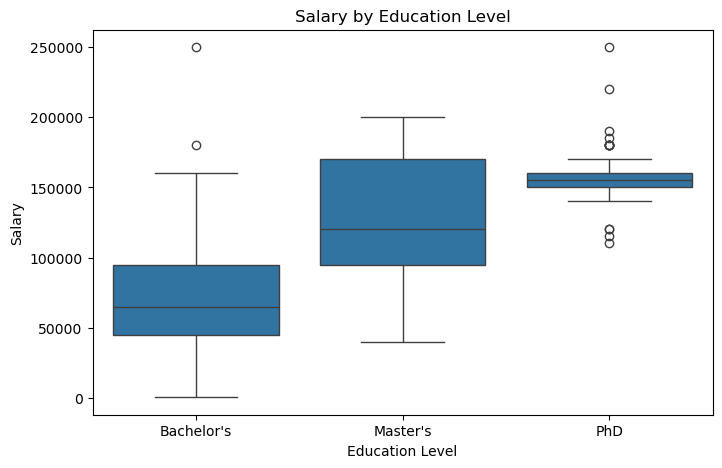

In [15]:

# Boxplot of Salary by Education Level
plt.figure(figsize=(8,5))
sns.boxplot(x='Education Level', y='Salary', data=df)
plt.title('Salary by Education Level')
plt.show()


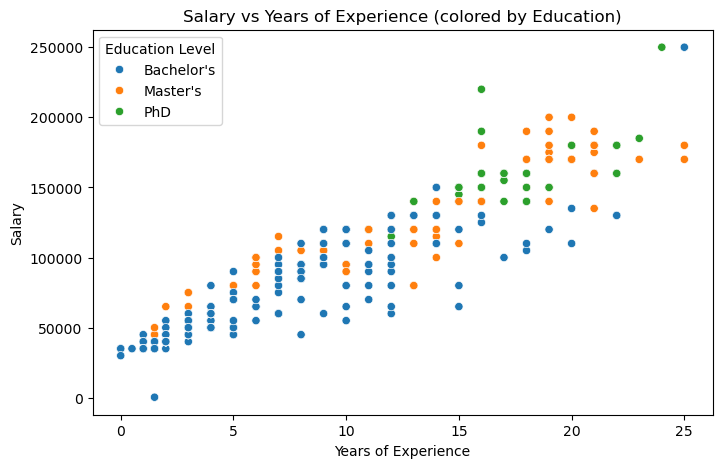

In [16]:

# Scatter plot: Salary vs Years of Experience
plt.figure(figsize=(8,5))
sns.scatterplot(x='Years of Experience', y='Salary', hue='Education Level', data=df)
plt.title('Salary vs Years of Experience (colored by Education)')
plt.show()

### Feature Engineering

In [17]:
edu_order = ['Bachelor\'s', 'Master\'s', 'PhD']

In [19]:
from sklearn.preprocessing import OrdinalEncoder
encoder = OrdinalEncoder(categories=[edu_order])
df['Education_Encoded'] = encoder.fit_transform(df[['Education Level']])

In [20]:
df[['Education Level', 'Education_Encoded']].drop_duplicates().sort_values('Education_Encoded')

,Education Level,Education_Encoded
0,Bachelor's,0.0
1,Master's,1.0
2,PhD,2.0


### Feature Selection

In [21]:
X = df[['Years of Experience', 'Education_Encoded']]
y = df['Salary']

In [22]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f'Training set size: {X_train.shape[0]}')
print(f'Test set size: {X_test.shape[0]}')

Training set size: 298
Test set size: 75


In [23]:
model = LinearRegression()

In [24]:
model.fit(X_train, y_train)

LinearRegression()

In [25]:
print(f'Intercept: {model.intercept_:.2f}')
print(f'Coefficients:')
for feature, coef in zip(X.columns, model.coef_):
    print(f'  {feature}: {coef:.2f}')

Intercept: 33733.33
Coefficients:
  Years of Experience: 5879.96
  Education_Encoded: 13963.78


In [32]:
# Predict on test set
y_pred = model.predict(X_test)

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100

print("MODEL PERFORMANCE REPORT")

print(f"R-squared (Explained Variance):  {r2:.2%}")
print(f"Mean Absolute Error (MAE):       ${mae:,.2f}")
print(f"Root Mean Squared Error (RMSE):  ${rmse:,.2f}")
print(f"Mean Absolute % Error (MAPE):    {mape:.2f}%")
print(f"-> Average Prediction Accuracy:  {100 - mape:.2f}%")

MODEL PERFORMANCE REPORT
R-squared (Explained Variance):  90.24%
Mean Absolute Error (MAE):       $11,104.79
Root Mean Squared Error (RMSE):  $15,297.30
Mean Absolute % Error (MAPE):    11.57%
-> Average Prediction Accuracy:  88.43%


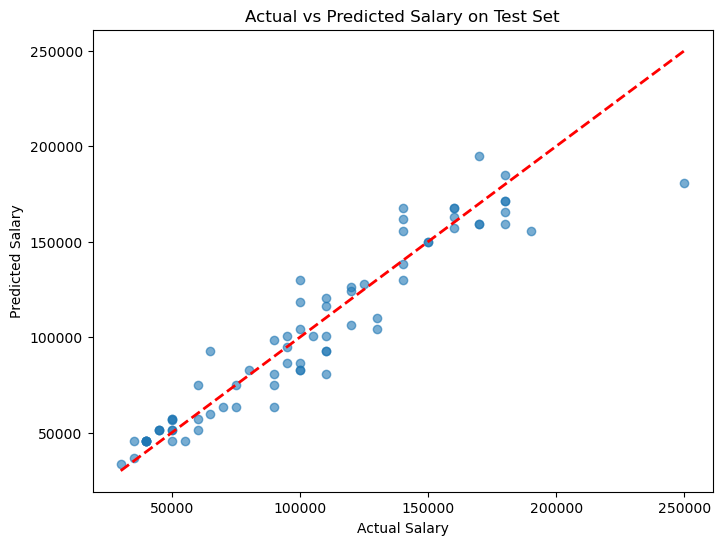

In [27]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Salary')
plt.ylabel('Predicted Salary')
plt.title('Actual vs Predicted Salary on Test Set')
plt.show()

Text(0.5, 1.0, 'Residual Distribution')

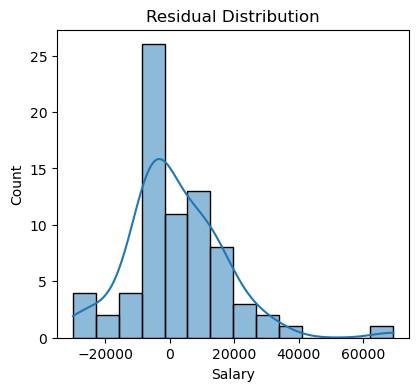

In [28]:
residuals = y_test - y_pred

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
sns.histplot(residuals, kde=True)
plt.title('Residual Distribution')

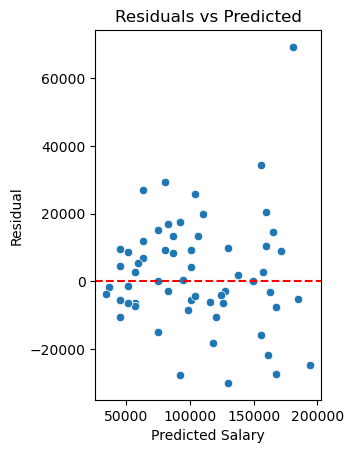

In [30]:

plt.subplot(1,2,2)
sns.scatterplot(x=y_pred, y=residuals)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Predicted Salary')
plt.ylabel('Residual')
plt.title('Residuals vs Predicted')
plt.show()

### Evaluation of Model

In [31]:
new_data = pd.DataFrame({
    'Years of Experience': [5, 10],
    'Education_Encoded': [1, 2]   # 1=Master's, 2=PhD
})

predictions = model.predict(new_data)
edu_labels = ["Bachelor's", "Master's", "PhD"]
for i, row in new_data.iterrows():
    print(f"Exp={row['Years of Experience']}, Edu={edu_labels[int(row['Education_Encoded'])]} => ${predictions[i]:,.2f}")

Exp=5, Edu=Master's => $77,096.93
Exp=10, Edu=PhD => $120,460.53
